# Drifing Gaussian

This is a simple case to develop a FEniCSx famework. It solves the depth-averaged advection-diffusion equation on a square grid.

$$
\begin{cases}
    \frac{\mathrm{d} \iota}{\mathrm{d} t} + \nabla \cdot (\iota \mathbf{v} - \mathbf{D} \nabla c) = 0 &x \in \Omega \\
    \iota = 0 &x \in \Gamma_{\mathrm{in}} \\
    \mathbf{D} \nabla c \cdot \mathbf{\hat{n}} = 0 & x \in \Gamma_{\mathrm{out}}
\end{cases}
$$

Using the LDG formulation, an auxiliary variable for the gradient is introduced. Although in the strong form, the equality is exact, later this will later be enforced weakly.

$$
$$

## Imports and Setup

In [1]:
import dolfinx as dx
import dolfinx.fem.petsc
import dolfinx.plot as dxp
from mpi4py import MPI
import numpy as np
from petsc4py import PETSc
import pyvista as pv
import ufl

In [2]:
pv.set_jupyter_backend('static')
plotter = pv.Plotter()

## Parameters

Here we give more specifics for the problem. Specifically we are solving for a constant rightward flow  and uniform diffusion in a square domain. The initial condition is a Gaussian bump, which should simply move rightwards and spread.

$$
\begin{align}
\mathbf{v} &= v_{0} \mathbf{\hat{e}}_{x} \\
\mathbf{D} &= D \mathbf{I} \\
\iota_{0}(\mathbf{x}) &= e^{-\frac{|\mathbf{x} - \mathbf{x}_{0}|^{2}}{2 \sigma^{2}}} \\
\iota(\mathbf{x}, t) &= \frac{\sigma^{2}}{\sigma^{2} + 2 d t} e^{-\frac{|\mathbf{x} - \mathbf{x}_{0} - \mathbf{v} t|^{2}}{2 (\sigma^{2} + 2 D t)}}
\end{align}
$$

In [3]:
h0 = 1.0 # Constant height
u0 = 1.0 # Constant rightward flow
v0 = 0.0 # No vertical flow
d0 = 0.05 # Isotropic diffusion
nx = 10 # Cell resolution
dt = 0.001 # Time step
nt = 1000
write_every = 10 # Only every nth frame
plot_speedup = 1 # Relative to sim time

In [4]:
# Initial condition
x0 = 0.5
y0 = 0.5
r0 = 0.1
def iota0(x):
    return np.exp(-((x[0] - x0) ** 2 + (x[1] - y0) ** 2)/ (2 * r0 ** 2))

In [5]:
# True solution
def iota_true(x, t):
    return r0 ** 2 / (r0 ** 2 + 2 * d0 * t) * np.exp(-((x[0] - x0) ** 2 + (x[1] - y0) ** 2)/ (2 * (r0 ** 2 + 2 * d0 * t)))

## Mesh

A simple unit square is used.

In [6]:
# Define a simple
domain = dx.mesh.create_unit_square(MPI.COMM_WORLD, nx, nx, cell_type=dx.mesh.CellType.triangle)

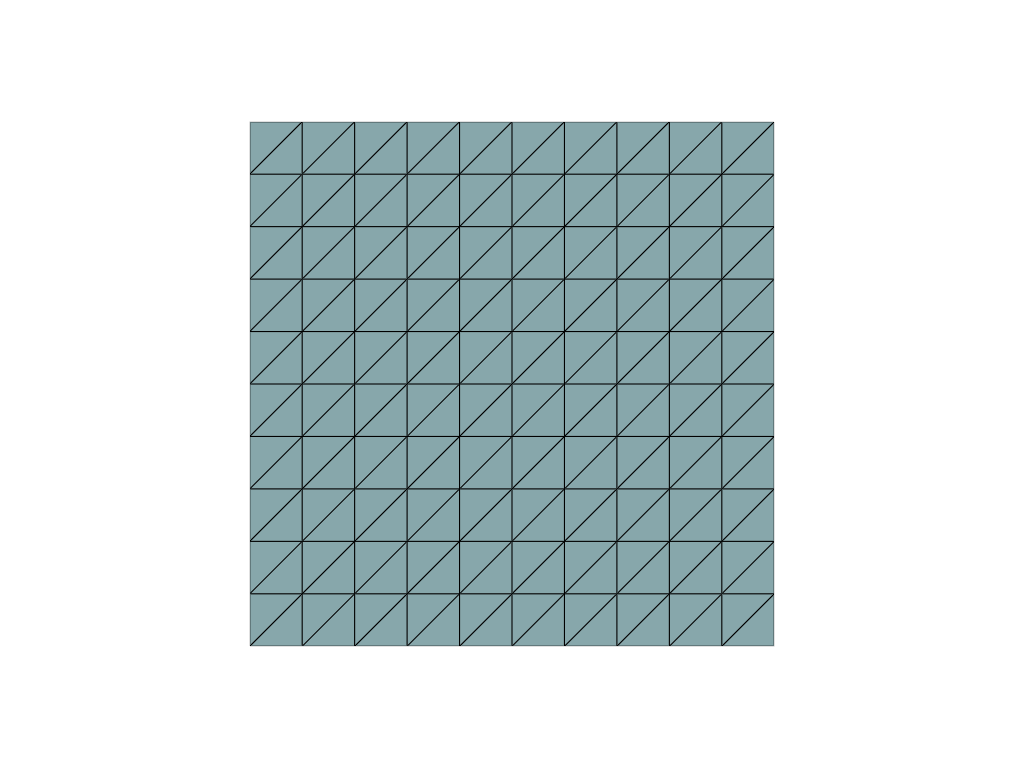

In [7]:
topology, cell_types, geometry = dxp.vtk_mesh(domain, domain.topology.dim)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
plotter.add_mesh(grid, show_edges=True, color="lightblue")
plotter.view_xy()
plotter.show()

## FEM Formulation

The weak form for this system is as follows.

$$
\begin{align}
\int_{\Omega_{e}} \left(\frac{\mathrm{d} q}{\mathrm{d}t} \phi - (\iota \mathbf{v} - h \mathbf{D} \mathbf{g}) \cdot \nabla \phi\right) \, \mathrm{d} \Omega + \int_{\partial \Omega_{e}} (\iota \mathbf{v} - h \mathbf{D} \mathbf{g}) \cdot \mathbf{\hat{n}} \phi \, \mathrm{d} \Gamma &= 0 \\
\int_{\Omega_{e}} \left( -\frac{\iota}{h} \nabla \cdot \boldsymbol{\psi} - \mathbf{g} \cdot \boldsymbol{\psi} \right) \, \mathrm{d} \Omega + \int_{\partial \Omega_{e}} \frac{\iota}{h} \boldsymbol{\psi} \cdot \mathbf{\hat{n}} \, \mathrm{d} \Gamma &= 0
\end{align}
$$

In FEniCSx, the residuals are simply combined.

One of the tricks of LDG is that, to maintain stability, the second equation uses a downwind, not upwind, flux.

In [8]:
# Linear DG space
V = dx.fem.functionspace(domain, ('Discontinuous Lagrange', 1))
W = dx.fem.functionspace(domain, ('Discontinuous Lagrange', 1, (domain.geometry.dim,)))

In [9]:
# Trial and test functions
dq_dt = ufl.TrialFunction(V) # Derivative of q
q = ufl.TrialFunction(V) # Conserved quantity iota = c * h
r = ufl.TrialFunction(W) # Gradient
phi = ufl.TestFunction(V) # Scalar test function
psi = ufl.TestFunction(W) # Vector test function

In [10]:
# FEM functions for solution loop
diota_dt = dx.fem.Function(V) # Not to be confused with trial function
diota_dt_vec = dx.la.petsc.create_vector_wrap(diota_dt.x) # For PETSc solve
iota = dx.fem.Function(V) # Conserved quantity iota = c * h
iota.interpolate(iota0)
g = dx.fem.Function(W) # Gradient of iota
g_vec = dx.la.petsc.create_vector_wrap(g.x)

In [11]:
# Additional functions
h = dx.fem.Constant(domain, h0)
v = dx.fem.Constant(domain, (u0, v0))
n = ufl.FacetNormal(domain)

In [12]:
# Manual upwinding and downwinding
# vn = ufl.dot(v, n)
# iota_upwind = ufl.conditional(vn('+') > 0.0, iota('+'), iota('-')) # Upwind
# F_boundary = F(iota_upwind)

In [13]:
# Use particular flux treatments
F_interior = q * v - h * d0 * r
vn = ufl.dot(v, n)
q_upwind = ufl.conditional(vn('+') > 0.0, q('+'), q('-'))
q_downwind = ufl.conditional(vn('+') > 0.0, q('-'), q('+'))
r_upwind = ufl.conditional(vn('+') > 0.0, r('+'), r('-'))
r_downwind = ufl.conditional(vn('+') > 0.0, r('-'), r('+'))
Fn_boundary = ufl.dot(q_upwind * v - h * d0 * r_upwind, n('+')) # Upwind
Fg_boundary = q_downwind / h # Downwind

In [14]:
# UFL form
# General form is dU/dt * phi + B(iota, phi) = 0
# M_g * r + B(iota, psi) = 0
M_form = dx.fem.form(dq_dt * phi * ufl.dx) # Mass matrix
B_interior = -ufl.dot(F_interior, ufl.grad(phi)) * ufl.dx
B_interior_facets = Fn_boundary * ufl.jump(phi) * ufl.dS
vn = ufl.dot(v, n)
B_boundary = ufl.conditional(vn > 0.0, q, dx.fem.Constant(domain, 0.0)) * vn * phi * ufl.ds # Not sure about BCs
RHS_form = dx.fem.form(ufl.replace(-B_interior - B_interior_facets - B_boundary, {q: iota, r: g})) # For explicit method
# Begin new forms
M_g_form = dx.fem.form(ufl.dot(r, psi) * ufl.dx) # Mass matrix for g
B_g_interior = q / h * ufl.div(psi) * ufl.dx
B_g_interior_facets = -Fg_boundary * ufl.jump(psi, n) * ufl.dS
B_g_boundary = -q / h * ufl.dot(psi, n) * ufl.ds
RHS_g_form = dx.fem.form(ufl.replace(-B_g_interior - B_g_interior_facets - B_g_boundary, {q: iota})) # For explicit method

## Assembly

In [15]:
# Assemble mass matrix
M = dx.fem.petsc.assemble_matrix(M_form)
M.assemble()

In [16]:
# Set up solver
# Serial only
M_solver = PETSc.KSP().create(domain.comm)
M_solver.setOperators(M)
M_solver.setType(PETSc.KSP.Type.PREONLY)
M_solver.getPC().setType(PETSc.PC.Type.LU)
M_solver.setFromOptions() # Allows command-line PETSc options to override the above
M_solver.setUp()

In [17]:
# Create RHS
b = dx.fem.petsc.create_vector(V)

In [18]:
# Assemble g mass matrix
M_g = dx.fem.petsc.assemble_matrix(M_g_form)
M_g.assemble()

In [19]:
# Set up solver
# Serial only
M_g_solver = PETSc.KSP().create(domain.comm)
M_g_solver.setOperators(M_g)
M_g_solver.setType(PETSc.KSP.Type.PREONLY)
M_g_solver.getPC().setType(PETSc.PC.Type.LU)
M_g_solver.setFromOptions() # Allows command-line PETSc options to override the above
M_g_solver.setUp()

In [20]:
# Create RHS
b_g = dx.fem.petsc.create_vector(W)

## Solution

In [21]:
# Set up PyVista plotting
topology, cell_types, geometry = dxp.vtk_mesh(V)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)
grid.point_data['iota'] = np.asarray(iota.x.array.real).copy()
plotter = pv.Plotter()
plotter.add_mesh(
    grid,
    scalars='iota',
    cmap='jet',
    clim=[0.0, 1.0],
    show_edges=False
)
plotter.view_xy()
# plotter.show()
plotter.open_gif('drifting_diffusing_gaussian.gif', fps=(plot_speedup * nt / write_every))

In [22]:
t = 0.0
for step in range(nt):
    if step % 100 == 0:
        print(f'Step {step:05d} of {nt:05d}')
    
    # Update time
    t = step * dt

    # Update g array
    with b_g.localForm() as local:
        local.set(0.0)
    dx.fem.petsc.assemble_vector(b_g, RHS_g_form)
    b_g.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)

    # Solve for g
    M_g_solver.solve(b_g, g_vec)
    g.x.scatter_forward()

    # Update iota array
    with b.localForm() as local:
        local.set(0.0)
    dx.fem.petsc.assemble_vector(b, RHS_form)
    b.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)

    # Solve for time derivative, M * iota_dot = b
    M_solver.solve(b, diota_dt_vec)
    diota_dt.x.scatter_forward()

    # Update only owned DOFs
    n_owned = (
        V.dofmap.index_map.size_local
        * V.dofmap.index_map_bs
    )

    # Forward Euler update
    iota.x.array[:n_owned] += dt * diota_dt.x.array[:n_owned] # Only n_owned for parallel
    iota.x.scatter_forward()

    # Write output to GIF
    if step % write_every == 0:
        grid.point_data['iota'] = np.asarray(iota.x.array.real).copy() # Make sure plotter is updated
        plotter.write_frame()

Step 00000 of 01000
Step 00100 of 01000
Step 00200 of 01000
Step 00300 of 01000
Step 00400 of 01000
Step 00500 of 01000
Step 00600 of 01000
Step 00700 of 01000
Step 00800 of 01000
Step 00900 of 01000


## Visualization

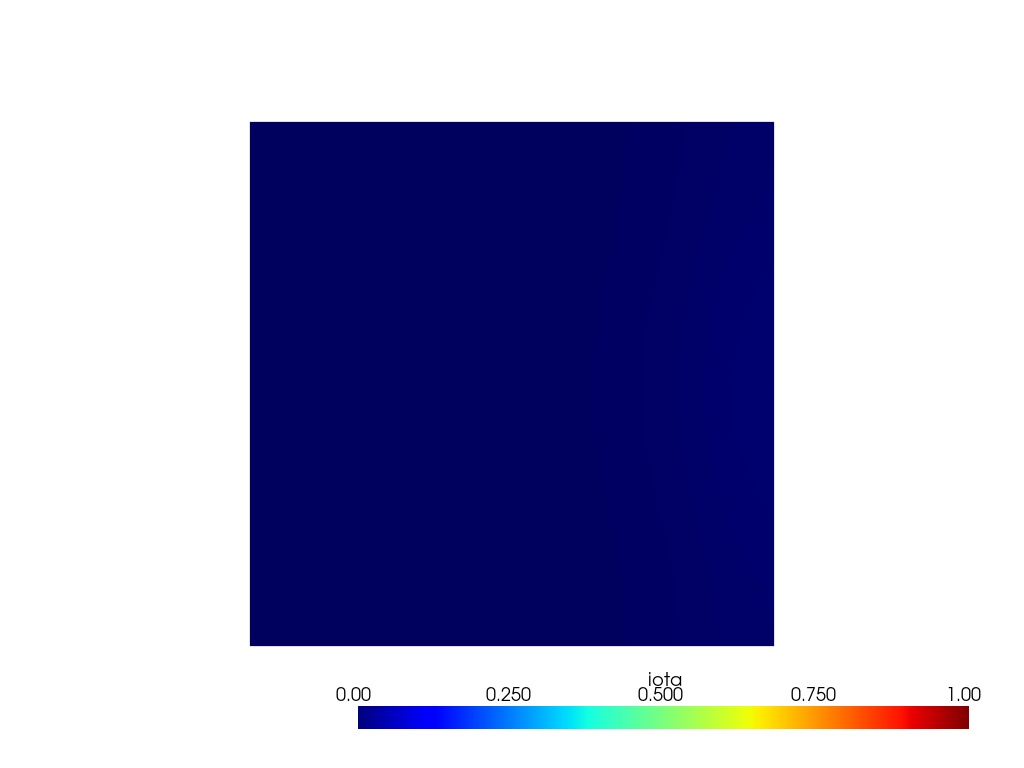

In [23]:
# See end result
plotter.show()

In [24]:
# Close and save file
plotter.close()